# DoubleML IRM - Impact of scholarship on dropout probability

This notebook aims at studying the impact of granting scholarships to students in higher education in Portugal on the probability of dropping out. 
- We will be studying only students who either completed their higher education or dropped out. 
- Our treatment variable is the dummy "scholarship" which indicates scholarship holders. Our outcome variable is a dummy variable as well, which is dropping out. 
- We use *Group Average Treatment Effects (GATE)* to investigate how these effects manifest across different segments of the risk of dropping out distribution. 

**Motivation**

It makes sense to assume that the effect of receiving a scholarship has *heterogeneous effects* on dropout, and at first-order, that the marginal effect of financial aid varies according to a student’s baseline propensity to drop out (assuming there is rank preservation).  

From a policy perspective, it is interesting to study if scholarships prevent the most at risk to pursue their studies. This gives a clearer picture of the extent of the realization of the initial goals of the scolarships: they are aimed at correcting social inequalities at the beginning of higher education; lower CES students tend to struggle with financial constraints which have a cognitive cost as well as a real cost on the time allocated to studies. These factors reduce the time allocated to human capital accumulation and significantly increase the risk of academic failure.

Furthermore, in a state of national budget contraction, identifying the distribution of these effects allows for more efficient resource allocation. If scholarships act as a necessary "safety net" that allows high-risk students to substitute labor hours for study time, then targeting these individuals maximizes the social return on public investment in education.

**Challenge for DoubleML with heterogeneous effects**

This task present two statistical challenges. 

- Class imbalance: our data doesn't have much dropouts. In order to make accurate predictions, usually in Machine Learning this imbalance is taken into account by reweighting the observations. However, this will probably result in some bias and violation of Neyman orthogonality, because reweighting is an issue of the same nature as the issue solved for when dealing with the regularization bias. Another non invasive procedure that we can do is to integrate the class imbalance issue when cross-fitting our data. Thus we apply the `StratifiedKFold` to reproduce the distribution of our classes in each fold. 
- High dimensionality of confounders X: This is one of the advantages of a DoubleML procedure actually: through feature selection techniques (regularization), or through decreasing complexity of models in general (pruning for tree-based models for ex) we are able to acheive better results than classical econometrics linear models. 


Note that initially, we wished to run a *quantile regression* with a non-linear (binary = logistic) model, however recent econometric work on binary quantile regression is not yet implemented in the package `DoubleML` (see Horowitz (1992) for kernel smoothing of the binary model, or Florios and Skouras (2008) who use mixed integer programming in order to compute estimates). 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
import warnings
from sklearn.base import clone
import multiprocessing
from sklearn.model_selection import StratifiedKFold

import doubleml as dml
warnings.filterwarnings('ignore')
from skrub import TableReport
from skrub import set_config
set_config(max_plot_columns=50)

# ── Style global ──────────────────────────────────────────────────
PALETTE_TARGET = {'Dropout': '#E63946', 'Graduate': '#2A9D8F', 'Enrolled': '#F4A261'}
PALETTE_BINARY = ['#E63946', '#2A9D8F']

sns.set_theme(style='whitegrid', palette='muted', font='DejaVu Sans')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.facecolor': 'white'
})


# 1. Fetching data

In [5]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
predict_students_dropout_and_academic_success = fetch_ucirepo(id=697) 
  
# data (as pandas dataframes) 
data_raw = predict_students_dropout_and_academic_success.data.features 
y_raw = predict_students_dropout_and_academic_success.data.targets 


In [6]:
# We will only keep the students that either dropped out or graduated, and drop the ones that are still enrolled.
# This way we can predict the probability of dropout on students that have already finished higher education. 
# We also encode the target variable as a binary variable, 1 being our state of interest = Dropout. 

mask = y_raw['Target'].isin(['Graduate', 'Dropout'])


data = data_raw[mask].copy()
y = y_raw[mask].copy()
y = y.replace({'Graduate': 0, 'Dropout': 1}).astype(int)



In [7]:
# One hot encoding of categorical variables and scaling of numerical variables (for DML with regularization, which is sensitive to feature scaling).

cat_features = ["Mother's occupation", "Father's occupation", "Mother's qualification", "Father's qualification", 
                "Course", "Previous qualification", 
                "Nacionality", "Marital Status", "Application order", "Application mode"
                ]

num_features = ["Admission grade","Age at enrollment", "Curricular units 1st sem (credited)", 
                "Curricular units 1st sem (enrolled)", "Curricular units 1st sem (evaluations)", 
                "Curricular units 1st sem (approved)", "Curricular units 1st sem (grade)", 
                "Curricular units 2nd sem (credited)", "Previous qualification (grade)",
                  "Curricular units 2nd sem (enrolled)", "Curricular units 2nd sem (evaluations)", 
                  "Curricular units 2nd sem (approved)", "Curricular units 2nd sem (grade)", 
                  "Unemployment rate", "Inflation rate", "GDP"]

other_features = data.columns.difference(cat_features + num_features).tolist()

preprocessor_dml = ColumnTransformer(transformers=[
    ('cat', Pipeline([
        ('stringify', FunctionTransformer(lambda x: x.astype(str), feature_names_out='one-to-one')),
        ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')) 
        # With regularization we can keep all categories, 
        # for other models that are not regularized (like decision trees and random forests):
        # actually the performance of these tree-based models is not affected by multicollinearity, 
        # but the interpretation of feature importance can be. In our causal context, we don't need to analyze feature importance.
        # we still drop the first category to be safe when adding more models.  
    ]), cat_features),
    ('num', Pipeline([
        ('scaler', StandardScaler())
    ]), num_features),
    ('passthrough', 'passthrough', other_features)
])

data_preprocessed = preprocessor_dml.fit_transform(data)

preprocessed_feature_names = (
    preprocessor_dml
    .named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(cat_features)
)
all_feature_names = list(preprocessed_feature_names) + num_features + other_features


data_preprocessed_df = pd.DataFrame(data_preprocessed, columns=all_feature_names)



In [165]:
# Basic table report
TableReport(data)

Processing column  36 / 36


,,,,,,,,,,,,,,,,,,,,,,,,,


# 2. Checking Common Support Assumption

We would like to suggest evidence that $P(Scholarship = 1 | X)$ is strictly bounded between 0 and 1; this way, we allow for some variability in our data and we are able to detect a causal effect of holding a scholarship on the probability of dropping out of studies. No need for now to remove students who are still enrolled. 

In particular, we have chosen to focus on a subset of students whose propensity score for getting a scholarship (based on the covariates we have identified in the DAG - see corresponding notebook) lies between **0.05 and 0.95**. 

In [8]:
# Confounders: variables with edges INTO both Scholarship holder AND Target
confounders_sociodemographic = [
    'Marital Status',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    'Nacionality',
    'Gender',
    'Age at enrollment',
    'Displaced',
    'Educational special needs',
    'International'
]

confounders_macroeconomic = [
    'Unemployment rate',
    'Inflation rate',
    'GDP'
]

# Academic factors: only point into Target, not into Scholarship
# Including them reduces variance of g_0(X) without introducing bias
academic_controls = [
    'Admission grade',
    'Previous qualification',
    'Previous qualification (grade)',
    'Course',
    'Daytime/evening attendance',
    'Application mode',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (without evaluations)'
]



features_small = confounders_sociodemographic + confounders_macroeconomic
features_full  = features_small + academic_controls

#Since the preprocessing the columns are dummified so the names have changed, for clarity of the notebook we still present them this way. 
def get_preprocessed_cols(feature_list, preprocessed_cols):
    return [
        col for col in preprocessed_cols
        if any(col == feat or col.startswith(feat + "_") for feat in feature_list)
    ]

features_small_pp = get_preprocessed_cols(
    confounders_sociodemographic + confounders_macroeconomic,
    data_preprocessed_df.columns
)
features_full_pp = get_preprocessed_cols(
    features_full,
    data_preprocessed_df.columns
)


features_clan_pp = get_preprocessed_cols(
    confounders_sociodemographic,
    data_preprocessed_df.columns
)


In [9]:


# Fit propensity score model
X = data_preprocessed_df[features_small_pp]
D = data_preprocessed_df['Scholarship holder']


In [10]:
# Dropout rate in the sample
dropout_rate = y['Target'].mean()
print(f"Dropout rate: {dropout_rate:.2%}")

Dropout rate: 39.15%


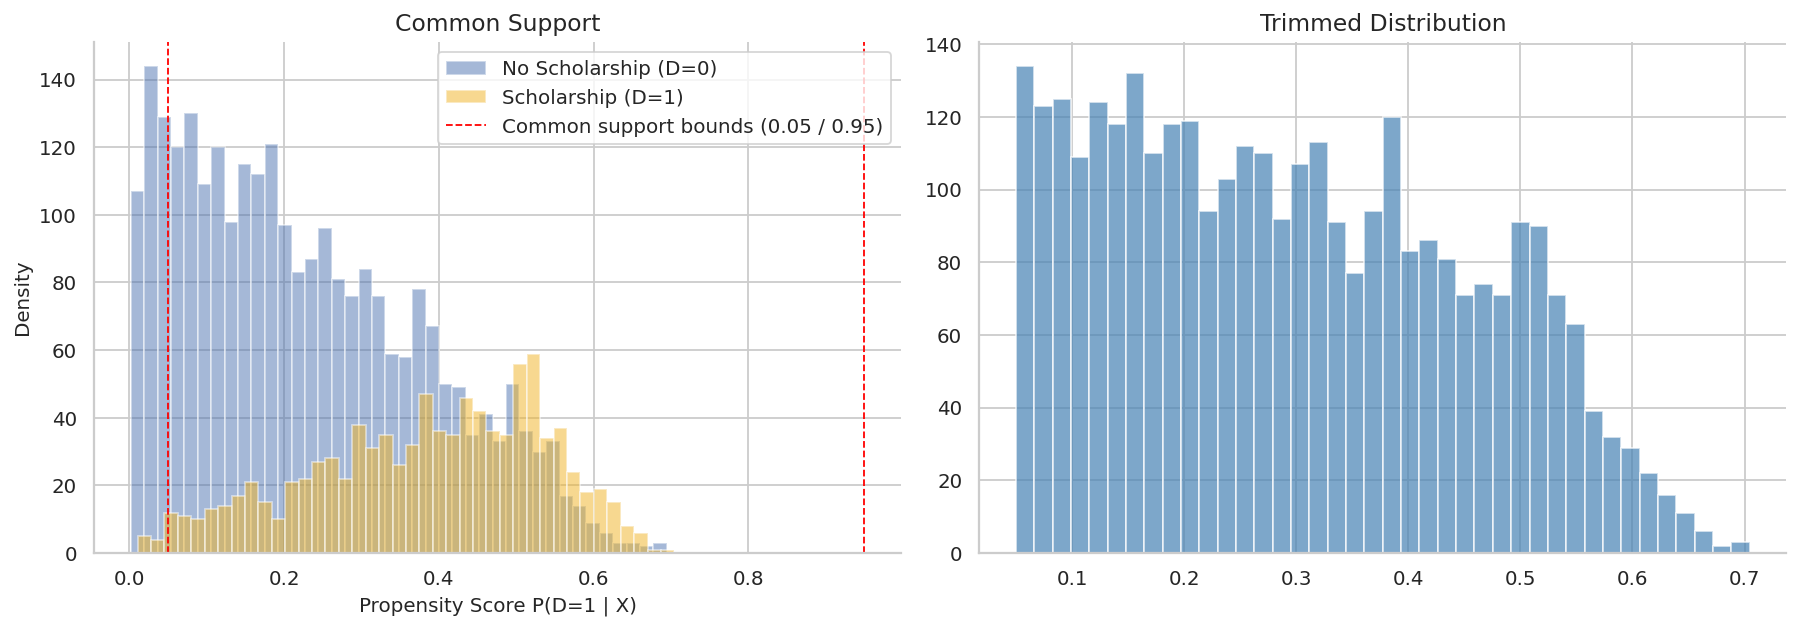

<Figure size 832x624 with 0 Axes>

Observations outside [0.05, 0.95] support: 10.0%
  Treated   outside support: 1.3%
  Untreated outside support: 13.2%


In [11]:

ps_model = LogisticRegressionCV(penalty='l1', solver='liblinear', cv=5, random_state=42)
ps_model.fit(X, D)
propensity_scores = ps_model.predict_proba(X)[:, 1]

# Split by treatment group
ps_treated   = propensity_scores[D == 1]
ps_untreated = propensity_scores[D == 0]

# Create the figure and an array of 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall histograms
axes[0].hist(ps_untreated, bins=40, alpha=0.5, color='#4C72B0', label='No Scholarship (D=0)')
axes[0].hist(ps_treated,   bins=40, alpha=0.5, color='#F0B323', label='Scholarship (D=1)')
axes[0].axvline(0.05, color='red', linestyle='--', linewidth=1, label='Common support bounds (0.05 / 0.95)')
axes[0].axvline(0.95, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Propensity Score P(D=1 | X)')
axes[0].set_ylabel('Density')
axes[0].set_title('Common Support')
axes[0].legend()

# Only for common support (propensity scores between 0.05 and 0.95)
in_support = (propensity_scores > 0.05) & (propensity_scores < 0.95)
axes[1].hist(propensity_scores[in_support], bins=40, color='steelblue', alpha=0.7)
axes[1].set_title('Trimmed Distribution')

plt.tight_layout()
plt.show()

# --- Plot 2: Trimmed overlap region ---

plt.tight_layout()
plt.show()

# Summary stats
pct_outside = (~in_support).mean() * 100
print(f"Observations outside [0.05, 0.95] support: {pct_outside:.1f}%")
print(f"  Treated   outside support: {(~in_support[D==1]).mean()*100:.1f}%")
print(f"  Untreated outside support: {(~in_support[D==0]).mean()*100:.1f}%")

In [12]:
# Characteristics of observations outside common support: do they systematically differ from those inside support?

balance_table = X.copy().assign(In_Support=in_support).groupby('In_Support')[features_small_pp ].mean().T
balance_table.columns = ['Outside Support', 'Inside Support']
balance_table['Absolute Difference'] = (balance_table['Inside Support'] - balance_table['Outside Support']).abs()
print("--- Balance Table: Inside vs. Outside Common Support ---")
balance_table.sort_values('Absolute Difference', ascending=False).head(20)

--- Balance Table: Inside vs. Outside Common Support ---


,Outside Support,Inside Support,Absolute Difference
Age at enrollment,1.660633,-0.185080,1.845713
Gender,0.730769,0.300980,0.429789
Displaced,0.307692,0.575934,0.268242
Marital Status_2,0.324176,0.063993,0.260183
GDP,-0.219606,0.024475,0.244081
Mother's qualification_3,0.266484,0.073484,0.192999
Mother's qualification_19,0.060440,0.231170,0.170730
Mother's occupation_2,0.214286,0.049602,0.164684
Unemployment rate,-0.144249,0.016077,0.160326
Inflation rate,0.142050,-0.015832,0.157881


In [13]:
# Keep only observations in common support for the rest of the analysis
if data_preprocessed_df.shape[0] != in_support.sum():
    print(f"Keeping only {in_support.sum()} observations in common support for the rest of the analysis (dropping {data_preprocessed_df.shape[0] - in_support.sum()} observations outside support).")
    data_preprocessed_df = data_preprocessed_df[in_support].reset_index(drop=True)
    data_preprocessed = data_preprocessed[in_support]
    y = y[in_support].reset_index(drop=True)
else:
    print("All observations are within common support, keeping all for the rest of the analysis.")

Keeping only 3266 observations in common support for the rest of the analysis (dropping 364 observations outside support).


In [14]:
# Dropout rate in the sample
dropout_rate = y['Target'].mean()
print(f"Dropout rate: {dropout_rate:.2%}")

Dropout rate: 36.25%


# 3. Double ML GATE

This first approach to heterogeneity is along one specific dimension that seemed crucial policy-wise: the baseline dropout probability in the absence of a scholarship. This approach resembles the one from Chernozhukov et al. (2020) on heterogeneous effects in randomized experiments yet here we don't perform a group ATE based on estimated score but only on estimated control mean. 

This approach suffers from different biases that Chernozhukov et al. (2020) do take into account, such as the plugging in of the estimated score in order to compute GATE (which is a stochastic object and not a deterministic indicator of belonging to a group), or the sample split based inference. 

Here, we still argue that the results are consistent with our hypothesis: effects are increasing in absolute value the more at risk the student is; and that it is a first step of the analysis worth exploring. 

In [15]:
# DoubleMLData backend 
data_dml = dml.DoubleMLData(
    data_preprocessed_df.assign(
        Target=y['Target'].values),
    y_col='Target',
    d_cols='Scholarship holder',
    x_cols=features_full_pp,
)


In [16]:
# Distribution of target variable by treatment group
pd.crosstab(data_preprocessed_df['Scholarship holder'], y['Target'])

Target,0,1
Scholarship holder,,
0.0,1254,1056
1.0,828,128


In [25]:
learners = {
    'Logistic L1': LogisticRegression(
        penalty='l1',
        solver='liblinear',
        max_iter=1000,
        random_state=42 #shuffling the data (not for cross-validation)
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=5,           
        min_samples_leaf=20,   
        n_jobs=-1,
        random_state=42
    ),
    'Neural Network': MLPClassifier(
        hidden_layer_sizes=(100, 50, 25),
        learning_rate_init=0.001,
        alpha=0.01, # L2 regularization
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    ), 
    'Boosting': GradientBoostingClassifier(
        n_estimators=100, 
        learning_rate=0.1, 
        max_depth=3, 
        random_state=42)
}

In [29]:
#DoubleML-IRM + GATES heterogeneity

results = {}

for learner_name, learner in learners.items():
    print(f"\n{'='*60}")
    print(f"Fitting DoubleML IRM — {learner_name}")
    print(f"{'='*60}")

    dml_irm = dml.DoubleMLIRM(
        data_dml,
        ml_g=clone(learner),
        ml_m=clone(learner),
        score='ATE',
        normalize_ipw=True,
        trimming_rule='truncate',
        trimming_threshold=0.05,
        draw_sample_splitting=False,
    )


    # Because of class imbalances, we use stratified splitting to ensure that
    # each fold has a representative proportion of treated and control observations

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    smpls = [(train, test) for train, test in skf.split(data_dml.x, data_dml.y)]
    dml_irm.set_sample_splitting(smpls).fit()

    ci  = dml_irm.confint(level=0.95)
    ate = float(dml_irm.coef[0])
    print(f"  ATE = {ate:.4f}   95% CI [{ci.iloc[0,0]:.4f}, {ci.iloc[0,1]:.4f}]")

    # ĝ₀(X) = out-of-sample prediction of E[Y | D=0, X]
    g0_hat = dml_irm.predictions['ml_g0'].squeeze()  # shape (n,)

    # GATES: 5 groups by risk quintile
    n_groups    = 5
    risk_labels = pd.qcut(g0_hat, q=n_groups, labels=[1, 2, 3, 4, 5])
    groups_df = pd.DataFrame(risk_labels)

    gate      = dml_irm.gate(groups=groups_df)
    gate_ci   = gate.confint(level=0.95, joint=False)   # pointwise
    gate_ci_j = gate.confint(level=0.95, joint=True)    # uniform band

    # ── BLP: formally test for heterogeneity ─────────────────────
    # H0: θ₁ = 0  (no systematic effect variation with risk)
    blp_basis = pd.DataFrame(
        {'risk_score': g0_hat - g0_hat.mean()},
    ).reset_index(drop=True)

    blp    = dml_irm.cate(basis=blp_basis)
    blp_ci = blp.confint(level=0.95)

    results[learner_name] = {
        'irm': dml_irm, 'ate': ate, 'ate_ci': ci,
        'g0_hat': g0_hat, 'risk_labels': risk_labels,
        'gate_ci': gate_ci, 'gate_ci_j': gate_ci_j,
        'blp_ci': blp_ci,
    }




Fitting DoubleML IRM — Logistic L1
  ATE = -0.0812   95% CI [-0.1057, -0.0566]

Fitting DoubleML IRM — Random Forest
  ATE = -0.1682   95% CI [-0.1980, -0.1384]

Fitting DoubleML IRM — Neural Network
  ATE = -0.0685   95% CI [-0.1067, -0.0304]

Fitting DoubleML IRM — Boosting
  ATE = -0.0882   95% CI [-0.1189, -0.0574]


In [30]:
results['Logistic L1']['gate_ci']

,2.5 %,effect,97.5 %
Group_1,-0.050639,-0.018943,0.012752
Group_2,-0.056571,-0.018564,0.019443
Group_3,-0.156001,-0.096685,-0.037368
Group_4,-0.339860,-0.246999,-0.154139
Group_5,-0.040757,-0.024825,-0.008894


In [31]:
#DoubleML-IRM + GATES heterogeneity

n_iterations = 100
results = {}


# Sample Split à la Chernozukhov: Main (M) and Auxiliary (A), in order to 
# compute the baseline risk g₀(X) on the auxiliary sample 
# and then compute GATES on the main sample using the auxiliary sample's predictions


for learner_name, learner in learners.items():
    all_gate_coefs = []
    all_gate_upper_cis = []
    all_gate_lower_cis = []
    all_ate_coefs = []
    all_ate_upper_cis = []
    all_ate_lower_cis = []


    print(f"\n{'='*60}",
          f"\nFitting DoubleIRM with split sampling... — {learner_name}\n",
          f"{'='*60}")
    
    for i in range(n_iterations):

    # Because of class imbalances, we use stratified splitting to ensure that
    # each fold has a representative proportion of treated and control observations

        print(f"\n{'='*60}",
          f"\nIteration {i+1}...\n",
          f"{'='*60}")
        
        stratify_cols = pd.Series(data_dml.y).astype(str) + "_" + pd.Series(data_dml.d.flatten()).astype(str)
        idx_m, idx_a = train_test_split(
            np.arange(data_dml.n_obs), 
            test_size=0.5, 
            random_state=i, # Changing seed each iteration
            stratify=stratify_cols
        )
        # Subset data for the two samples
        data_dml_m = dml.DoubleMLData.from_arrays(
            x = data_dml.x[idx_m, :],
            y = data_dml.y[idx_m],
            d = data_dml.d[idx_m]
        )
        
        data_dml_a = dml.DoubleMLData.from_arrays(
            x = data_dml.x[idx_a, :],
            y = data_dml.y[idx_a],
            d = data_dml.d[idx_a]
        )

        learner_g0 = clone(learner)
        X_a_ctrl = data_dml_a.x[data_dml_a.d.flatten() == 0]
        y_a_ctrl = data_dml_a.y[data_dml_a.d.flatten() == 0]
        learner_g0.fit(X_a_ctrl, y_a_ctrl)
        
        print(f"\n{'='*60}")
        print(f"Fitting DoubleML IRM — {learner_name}")
        print(f"{'='*60}")

        dml_irm = dml.DoubleMLIRM(
            data_dml_m,
            ml_g=clone(learner),
            ml_m=clone(learner),
            score='ATE',
            normalize_ipw=True,
            trimming_rule='truncate',
            trimming_threshold=0.05,
            draw_sample_splitting=False,
        )

        # Stratification again for class imbalance reasons

        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        smpls = [(train, test) for train, test in skf.split(data_dml_m.x, data_dml_m.y)]

        # Fit on sample M
        dml_irm.set_sample_splitting(smpls).fit()


        # ATE Estimation and confidence interval
        ate = float(dml_irm.coef[0])
        ci  = dml_irm.confint(level=0.95)

        all_ate_coefs.append(ate)
        all_ate_lower_cis.append(ci.iloc[0, 0])
        all_ate_upper_cis.append(ci.iloc[0, 1])

        print(f"  ATE = {ate:.4f}   95% CI [{ci.iloc[0,0]:.4f}, {ci.iloc[0,1]:.4f}]")

        # ĝ₀(X) = out-of-sample prediction of E[Y | D=0, X]
        g0_hat_m = learner_g0.predict_proba(data_dml_m.x)[:, 1]

        # GATES: 5 groups by risk quintile
        n_groups    = 5
        risk_labels = pd.qcut(g0_hat_m, q=n_groups, labels=[1, 2, 3, 4, 5])
        groups_df = pd.DataFrame(risk_labels)

        gate      = dml_irm.gate(groups=groups_df)
        gate_ci   = gate.confint(level=0.95, joint=False)   # pointwise
        current_coefs = gate_ci['effect'].values
        current_lower = gate_ci['2.5 %'].values
        current_upper = gate_ci['97.5 %'].values

        # Add upper and lower bounds of the pointwise confidence intervals
        # to the list (going to get the median of the upper and lower bounds
        #  across iterations for each group)
        all_gate_coefs.append(current_coefs)
        all_gate_lower_cis.append(current_lower)
        all_gate_upper_cis.append(current_upper)


    #Get the median for each group across iterations of {γ_hat_k,A} and {l(0.05)A, u(0.05)A}. 
    median_ate_coefs = np.nanmedian(np.array(all_ate_coefs), axis=0)
    median_ate_lower = np.nanmedian(np.array(all_ate_lower_cis), axis=0)
    median_ate_upper = np.nanmedian(np.array(all_ate_upper_cis), axis=0)

    median_gate_coefs = np.nanmedian(np.array(all_gate_coefs), axis=0)
    median_gate_lower = np.nanmedian(np.array(all_gate_lower_cis), axis=0)
    median_gate_upper = np.nanmedian(np.array(all_gate_upper_cis), axis=0)


    results[learner_name] = {
        'irm': dml_irm,
        'ate_coef':median_ate_coefs, 
        'ate_ci_lower': median_ate_lower, 
        'ate_ci_upper': median_ate_upper,
        'risk_labels': risk_labels,
        'gate_coefs': median_gate_coefs,
        'gate_ci_lower': median_gate_lower,
        'gate_ci_upper': median_gate_upper} # replace this object with the median of the upper and lower bounds of the pointwise confidence intervals across iterations for each group, and the median of the gate coefficients across iterations for each group.




Fitting DoubleIRM with split sampling... — Logistic L1

Iteration 1...

Fitting DoubleML IRM — Logistic L1
  ATE = -0.0957   95% CI [-0.1368, -0.0547]

Iteration 2...

Fitting DoubleML IRM — Logistic L1
  ATE = -0.0746   95% CI [-0.1125, -0.0367]

Iteration 3...

Fitting DoubleML IRM — Logistic L1
  ATE = -0.0653   95% CI [-0.0998, -0.0308]

Iteration 4...

Fitting DoubleML IRM — Logistic L1
  ATE = -0.0804   95% CI [-0.1158, -0.0450]

Iteration 5...

Fitting DoubleML IRM — Logistic L1
  ATE = -0.0744   95% CI [-0.1134, -0.0354]

Iteration 6...

Fitting DoubleML IRM — Logistic L1
  ATE = -0.0787   95% CI [-0.1189, -0.0384]

Iteration 7...

Fitting DoubleML IRM — Logistic L1
  ATE = -0.0898   95% CI [-0.1290, -0.0506]

Iteration 8...

Fitting DoubleML IRM — Logistic L1
  ATE = -0.0860   95% CI [-0.1229, -0.0492]

Iteration 9...

Fitting DoubleML IRM — Logistic L1
  ATE = -0.0948   95% CI [-0.1324, -0.0572]

Iteration 10...

Fitting DoubleML IRM — Logistic L1
  ATE = -0.0797   95% CI [-

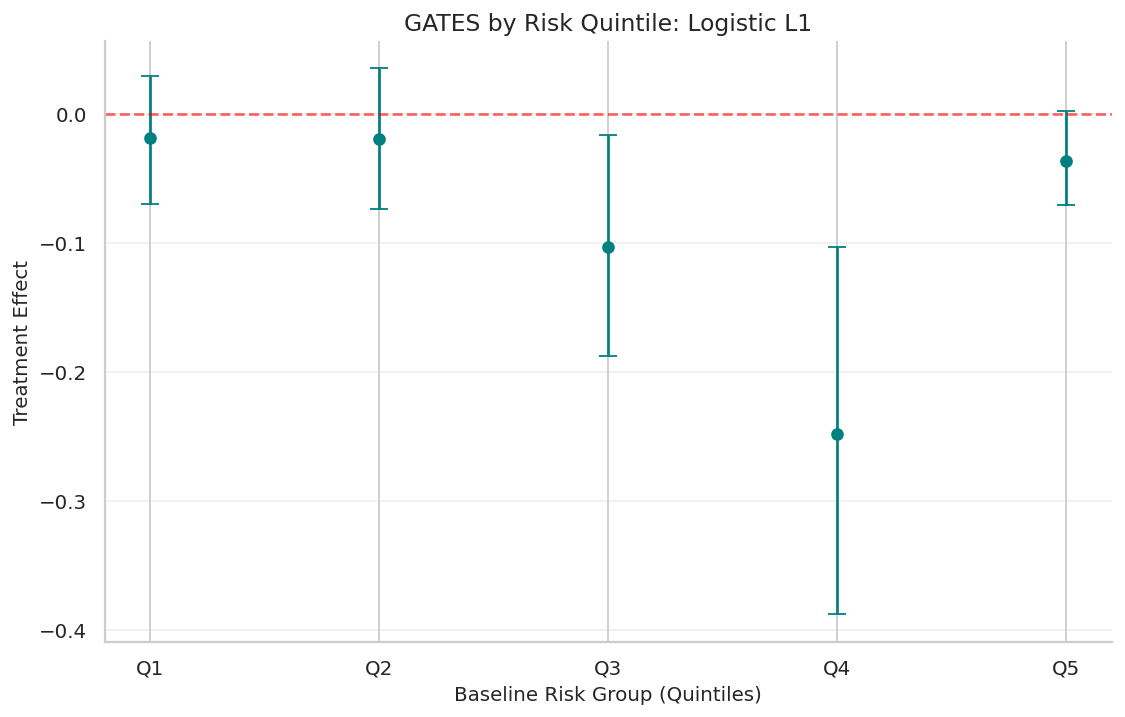

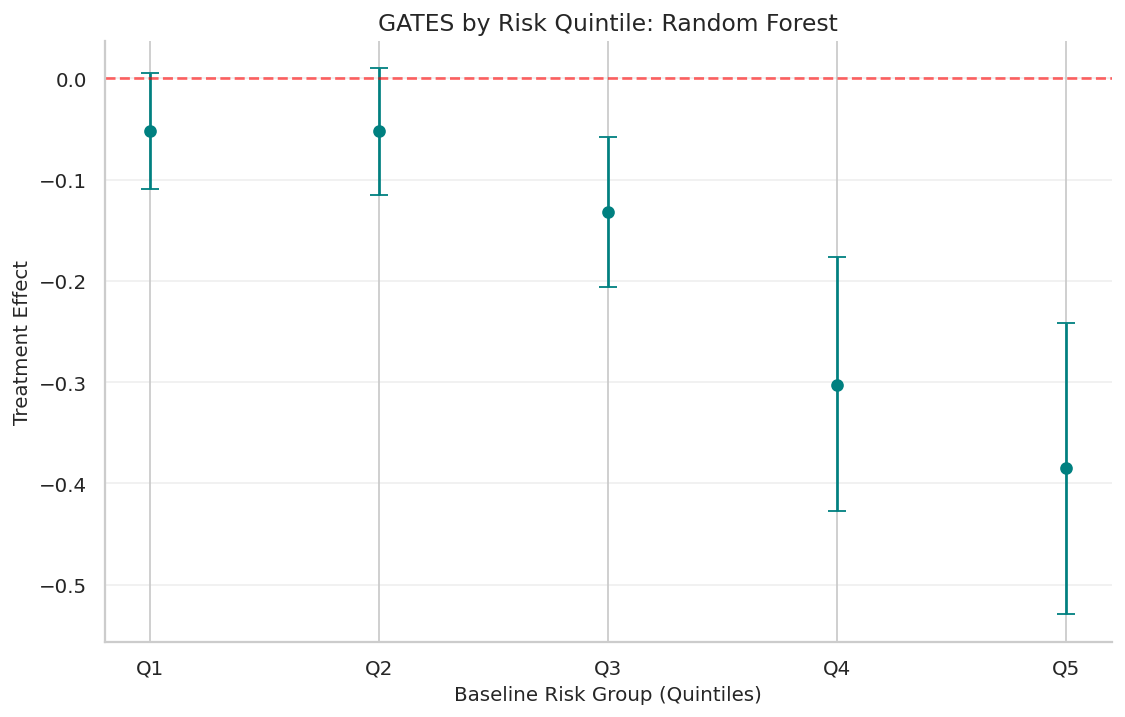

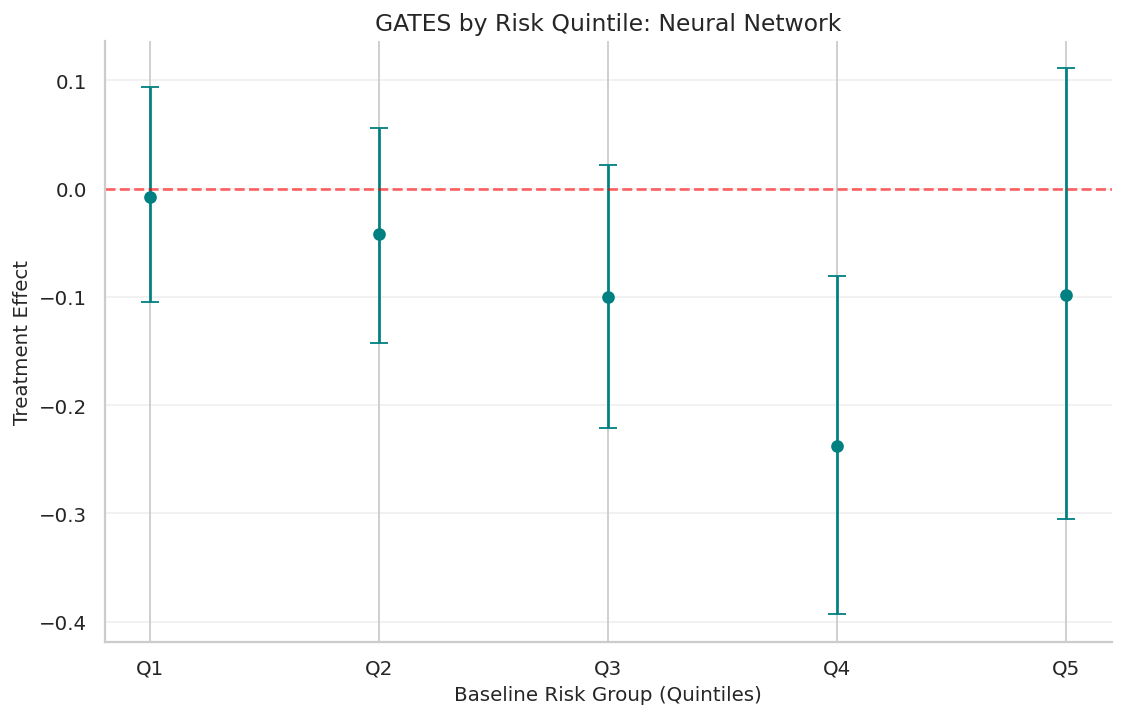

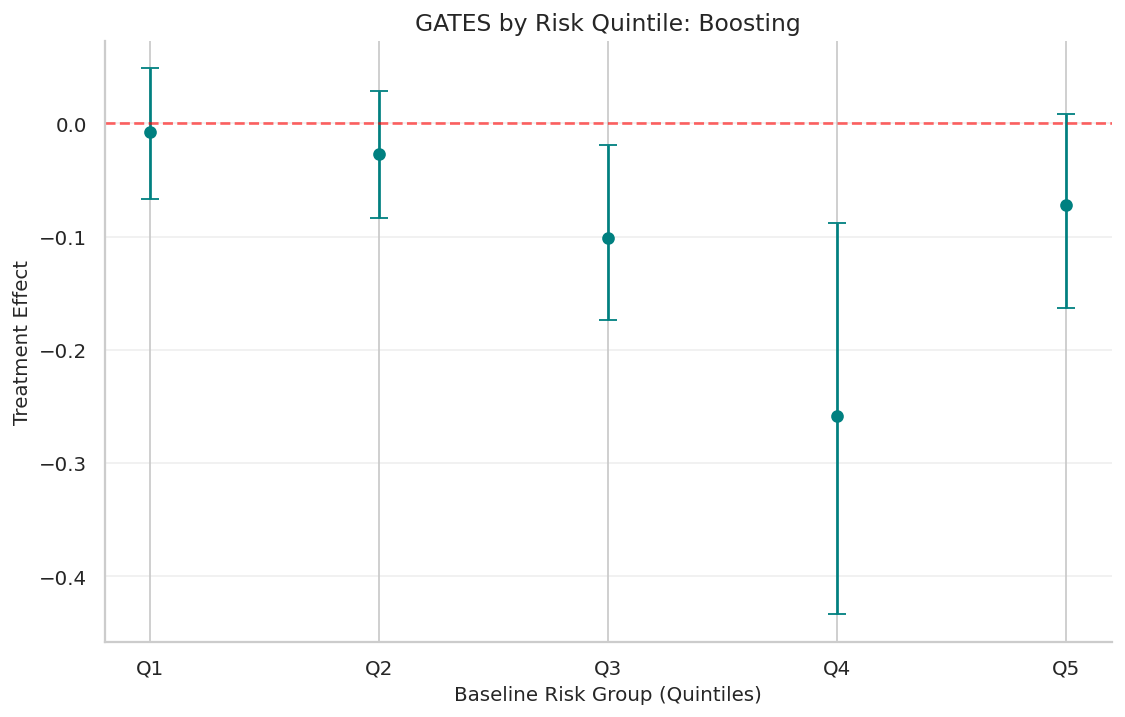

In [32]:
def get_stars(lower, upper):
    if lower > 0 or upper < 0:
        return "***"  # Simplified heuristic for CI-based significance
    return ""

summary_data = []

for learner_name, res in results.items():
    # 1. Plotting GATES
    plt.figure(figsize=(10, 6))
    groups = [f"Q{i+1}" for i in range(len(res['gate_coefs']))]
    
    # Calculate error bars for plt.errorbar (requires relative offsets)
    yerr_lower = res['gate_coefs'] - res['gate_ci_lower']
    yerr_upper = res['gate_ci_upper'] - res['gate_coefs']
    
    plt.errorbar(groups, res['gate_coefs'], yerr=[yerr_lower, yerr_upper], 
                 fmt='o', capsize=5, color='teal', label='GATE')
    
    plt.axhline(0, color='red', linestyle='--', alpha=0.6)
    plt.title(f"GATES by Risk Quintile: {learner_name}")
    plt.ylabel("Treatment Effect")
    plt.xlabel("Baseline Risk Group (Quintiles)")
    # plt.set_xticklabels([f'Q{i+1}\n{"(lowest risk)" if i==0 else "(highest risk)" if i==4 else ""} '
    #                     for i in range(len(res['gate_coefs']))], fontsize=9)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    # 2. Collect data for Tables
    # Add ATE
    summary_data.append({
        'Learner': learner_name,
        'Group': 'Full Sample (ATE)',
        'Estimate': res['ate_coef'],
        'Lower CI': res['ate_ci_lower'],
        'Upper CI': res['ate_ci_upper'],
        'Stars': get_stars(res['ate_ci_lower'], res['ate_ci_upper'])
    })
    
    # Add GATES
    for i in range(len(res['gate_coefs'])):
        summary_data.append({
            'Learner': learner_name,
            'Group': f"Quintile {i+1}",
            'Estimate': res['gate_coefs'][i],
            'Lower CI': res['gate_ci_lower'][i],
            'Upper CI': res['gate_ci_upper'][i],
            'Stars': get_stars(res['gate_ci_lower'][i], res['gate_ci_upper'][i])
        })

df_results = pd.DataFrame(summary_data)


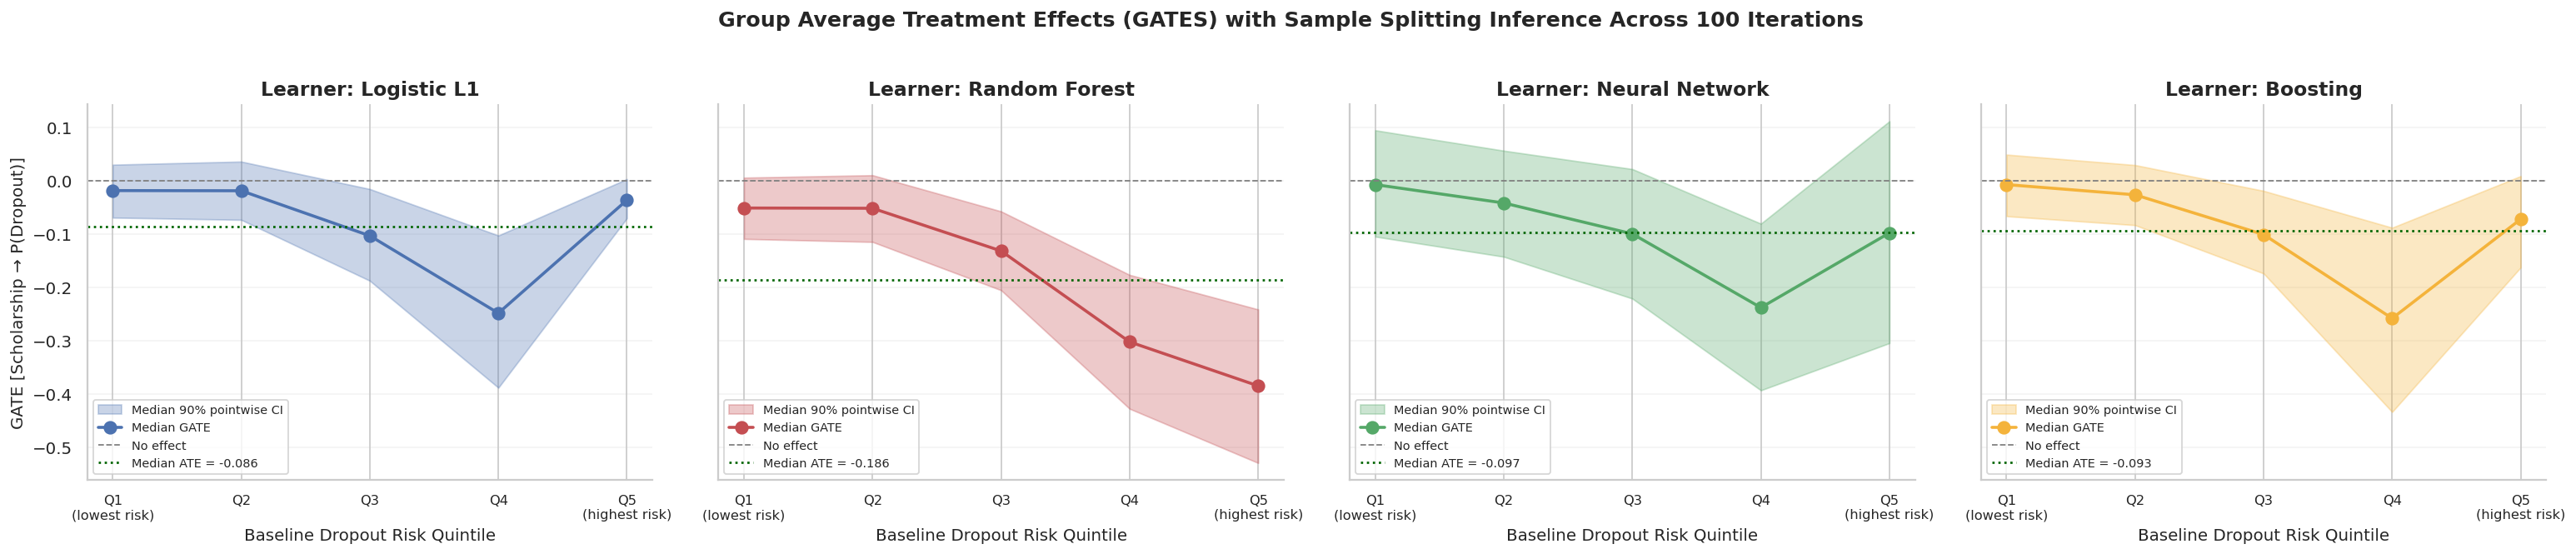

In [39]:
# Define colors to match your original style
colors = {'Logistic L1': '#4C72B0', 'Neural Network': '#55A868','Boosting': "#F4B33B", 'Random Forest': '#C44E52'}
n_groups = 5

# Create the figure
fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5), sharey=True)

# Handle case where there's only one learner (axes wouldn't be a list)
if len(results) == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, results.items()):
    c = colors.get(name, '#333333')
    
    # Extract median values stored in your results dict
    coef  = res['gate_coefs']
    lo_pw = res['gate_ci_lower']
    hi_pw = res['gate_ci_upper']
    ate   = res['ate_coef']
    
    x = np.arange(1, n_groups + 1)

    # 1. Shaded area for Pointwise Confidence Interval
    ax.fill_between(x, lo_pw, hi_pw, alpha=0.3, color=c, label='Median 90% pointwise CI')
    
    # 2. Plot the median coefficients
    ax.plot(x, coef, 'o-', color=c, markersize=8, linewidth=2, label='Median GATE')
    
    # 3. Reference lines
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, label='No effect')
    ax.axhline(ate, color='darkgreen', linestyle=':', linewidth=1.5, 
               label=f'Median ATE = {ate:.3f}')
    
    # 4. Formatting labels
    ax.set_xticks(x)
    labels = [f'Q{i}\n{"(lowest risk)" if i==1 else "(highest risk)" if i==5 else ""}' for i in x]
    ax.set_xticklabels(labels, fontsize=9)
    
    ax.set_title(f"Learner: {name}", fontweight='bold')
    ax.set_xlabel('Baseline Dropout Risk Quintile')
    if ax == axes[0]:
        ax.set_ylabel('GATE [Scholarship → P(Dropout)]')
    
    ax.legend(fontsize=8, loc='best')
    ax.grid(axis='y', alpha=0.2)

plt.suptitle('Group Average Treatment Effects (GATES) with Sample Splitting Inference Across 100 Iterations', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [37]:

# Summary Table of ATE and GATES results
print("### Results Summary Table")
df_results



### Results Summary Table


,Learner,Group,Estimate,Lower CI,Upper CI,Stars
0,Logistic L1,Full Sample (ATE),-0.086166,-0.124822,-0.047615,***
1,Logistic L1,Quintile 1,-0.018825,-0.069517,0.029669,
2,Logistic L1,Quintile 2,-0.019141,-0.073623,0.035489,
3,Logistic L1,Quintile 3,-0.103531,-0.187799,-0.015937,***
4,Logistic L1,Quintile 4,-0.248522,-0.388219,-0.103035,***
5,Logistic L1,Quintile 5,-0.036690,-0.070598,0.002757,
6,Random Forest,Full Sample (ATE),-0.185913,-0.230574,-0.141260,***
7,Random Forest,Quintile 1,-0.051492,-0.109432,0.005355,
8,Random Forest,Quintile 2,-0.051981,-0.115023,0.009977,
9,Random Forest,Quintile 3,-0.131903,-0.205516,-0.057790,***


In [38]:
# Summary Table for final presentation

print("\n### LaTeX Code")
latex_code = df_results.copy()
latex_code['Estimate'] = latex_code.apply(
    lambda x: f"{x['Estimate']:.3f}^{{{x['Stars']}}}", axis=1
)
latex_code['CI'] = latex_code.apply(
    lambda x: f"({x['Lower CI']:.3f}, {x['Upper CI']:.3f})", axis=1
)
print(latex_code[['Learner', 'Group', 'Estimate', 'CI']].to_latex(index=False, escape=False))


### LaTeX Code
\begin{tabular}{llll}
\toprule
Learner & Group & Estimate & CI \\
\midrule
Logistic L1 & Full Sample (ATE) & -0.086^{***} & (-0.125, -0.048) \\
Logistic L1 & Quintile 1 & -0.019^{} & (-0.070, 0.030) \\
Logistic L1 & Quintile 2 & -0.019^{} & (-0.074, 0.035) \\
Logistic L1 & Quintile 3 & -0.104^{***} & (-0.188, -0.016) \\
Logistic L1 & Quintile 4 & -0.249^{***} & (-0.388, -0.103) \\
Logistic L1 & Quintile 5 & -0.037^{} & (-0.071, 0.003) \\
Random Forest & Full Sample (ATE) & -0.186^{***} & (-0.231, -0.141) \\
Random Forest & Quintile 1 & -0.051^{} & (-0.109, 0.005) \\
Random Forest & Quintile 2 & -0.052^{} & (-0.115, 0.010) \\
Random Forest & Quintile 3 & -0.132^{***} & (-0.206, -0.058) \\
Random Forest & Quintile 4 & -0.302^{***} & (-0.428, -0.177) \\
Random Forest & Quintile 5 & -0.385^{***} & (-0.529, -0.242) \\
Neural Network & Full Sample (ATE) & -0.097^{***} & (-0.161, -0.032) \\
Neural Network & Quintile 1 & -0.008^{} & (-0.105, 0.094) \\
Neural Network & Quintile 